<a href="https://colab.research.google.com/github/MalshanRuchira/NorthStar-Analytics-Project/blob/main/NorthStar_Main_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

app_events = pd.read_csv('https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/app_events.csv')
complaints = pd.read_csv('https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/complaints.csv')
customers = pd.read_csv('https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/customers.csv')
deliveries = pd.read_csv('https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/deliveries.csv')
drivers = pd.read_csv('https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/drivers.csv')
hubs = pd.read_csv('https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/hubs.csv')
incidents = pd.read_csv('https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/incidents.csv')
orders = pd.read_csv('https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/orders.csv')
vehicles = pd.read_csv('https://raw.githubusercontent.com/MalshanRuchira/NorthStar-Analytics-Project/refs/heads/main/vehicles.csv')

datasets = {
    "Complaints": complaints, "Customers": customers, "Deliveries": deliveries,
    "Drivers": drivers, "Incidents": incidents, "Orders": orders, "Vehicles": vehicles
}

print("--- MISSING VALUE ANALYSIS ---")
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print(f"\n{name} Missing Values:")
        print(missing)

--- MISSING VALUE ANALYSIS ---

Complaints Missing Values:
compensation_amount    16
dtype: int64

Customers Missing Values:
loyalty_score        20
preferred_channel    13
dtype: int64

Deliveries Missing Values:
delivery_completed_at            19
customer_rating_post_delivery    14
dtype: int64

Drivers Missing Values:
training_score    7
dtype: int64

Incidents Missing Values:
resolved_hours    17
dtype: int64

Orders Missing Values:
booking_channel    25
dtype: int64

Vehicles Missing Values:
battery_health_pct    4
dtype: int64


In [3]:
zone_mappings = [
    (app_events, 'zone_context'), (customers, 'home_zone'),
    (orders, 'pickup_zone'), (orders, 'dropoff_zone'),
    (drivers, 'base_zone'), (vehicles, 'assigned_zone'), (hubs, 'zone')
]

for df, col in zone_mappings:
    df[col] = df[col].astype(str).str.title().str.strip()

customers['loyalty_score'] = customers['loyalty_score'].fillna(customers['loyalty_score'].median())
drivers['training_score'] = drivers['training_score'].fillna(drivers['training_score'].median())
vehicles['battery_health_pct'] = vehicles['battery_health_pct'].fillna(vehicles['battery_health_pct'].median())
deliveries['customer_rating_post_delivery'] = deliveries['customer_rating_post_delivery'].fillna(deliveries['customer_rating_post_delivery'].median())
incidents['resolved_hours'] = incidents['resolved_hours'].fillna(incidents['resolved_hours'].median())

complaints['compensation_amount'] = complaints['compensation_amount'].fillna(0)

customers['preferred_channel'] = customers['preferred_channel'].fillna(customers['preferred_channel'].mode()[0])
orders['booking_channel'] = orders['booking_channel'].fillna(orders['booking_channel'].mode()[0])

print("\nCleaning complete. Inconsistent zones fixed and missing values imputed.")


Cleaning complete. Inconsistent zones fixed and missing values imputed.


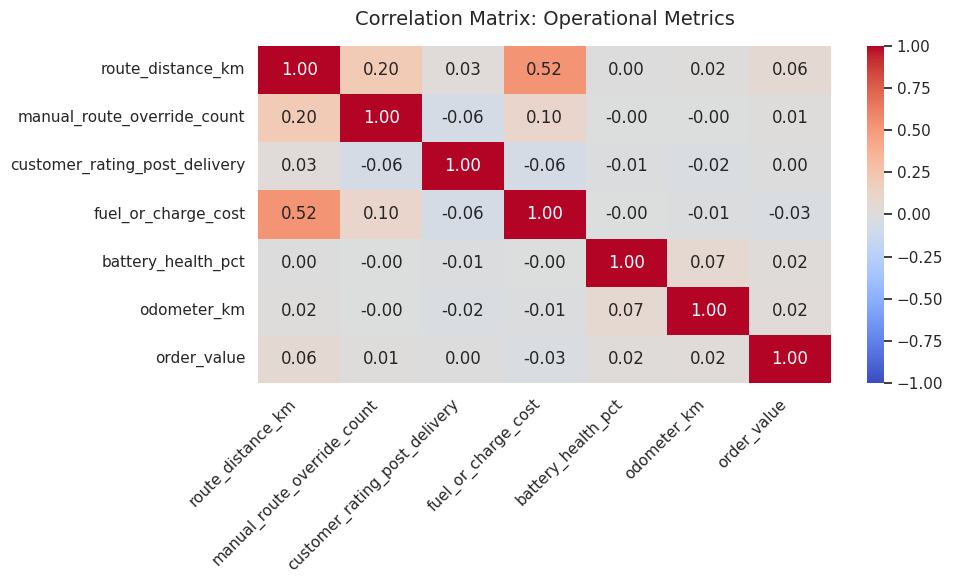

In [4]:
merged_ops = deliveries.merge(vehicles, on='vehicle_id', how='left')
merged_ops = merged_ops.merge(orders, on='order_id', how='left')

numeric_cols = ['route_distance_km', 'manual_route_override_count',
                'customer_rating_post_delivery', 'fuel_or_charge_cost',
                'battery_health_pct', 'odometer_km', 'order_value']

corr_matrix = merged_ops[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix: Operational Metrics", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

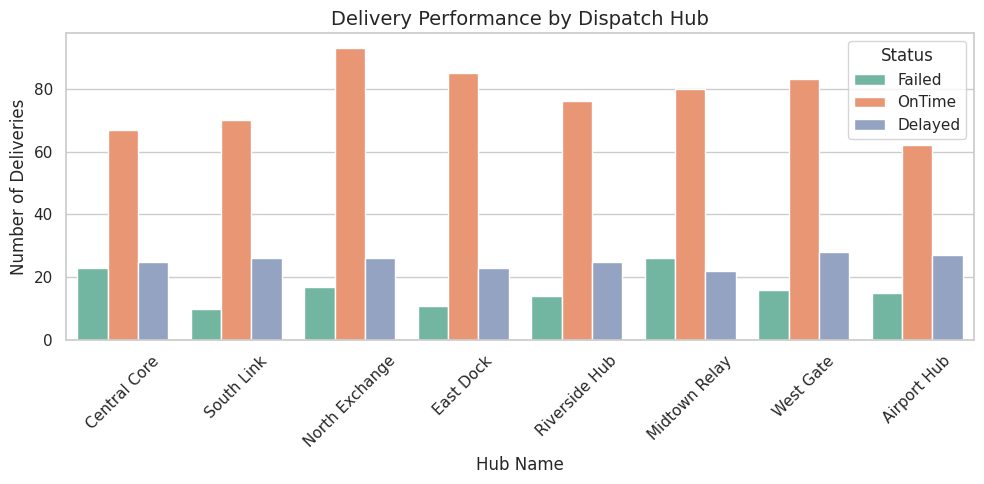

In [5]:
del_hubs = deliveries.merge(hubs, on='hub_id', how='left')

plt.figure(figsize=(10, 5))
sns.countplot(data=del_hubs, x='hub_name', hue='delivery_status', palette='Set2')
plt.title("Delivery Performance by Dispatch Hub", fontsize=14)
plt.xlabel("Hub Name")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=45)
plt.legend(title="Status")
plt.tight_layout()
plt.savefig('chart_1.png')
plt.show()

/tmp/ipykernel_3688/2007140253.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=complaints, y='complaint_type', order=order, palette='Reds_r')


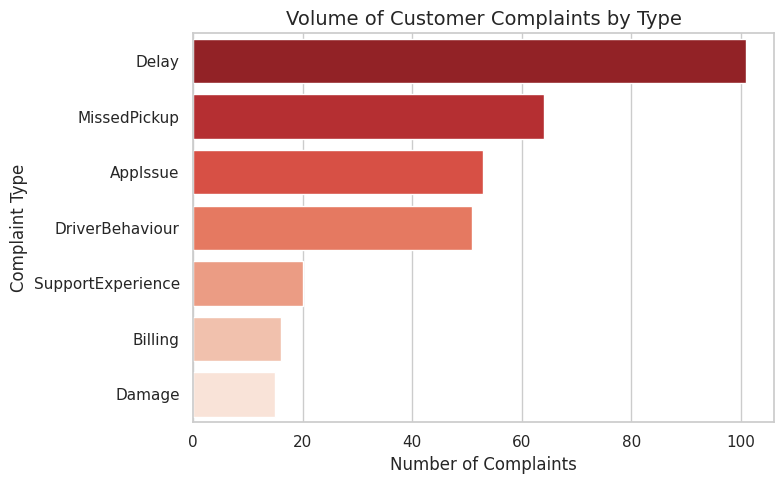

In [6]:
plt.figure(figsize=(8, 5))
order = complaints['complaint_type'].value_counts().index
sns.countplot(data=complaints, y='complaint_type', order=order, palette='Reds_r')
plt.title("Volume of Customer Complaints by Type", fontsize=14)
plt.xlabel("Number of Complaints")
plt.ylabel("Complaint Type")
plt.tight_layout()
plt.savefig('chart_2.png')
plt.show()

/tmp/ipykernel_3688/1522062925.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vehicles, x='maintenance_status', y='battery_health_pct', palette='viridis')


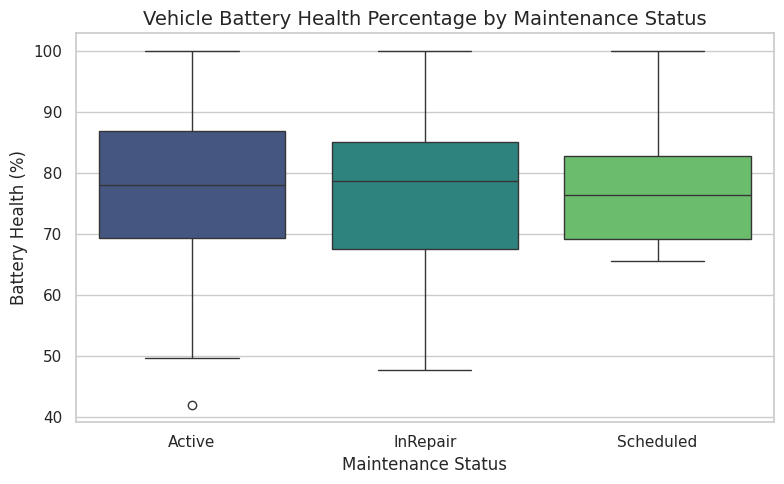

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=vehicles, x='maintenance_status', y='battery_health_pct', palette='viridis')
plt.title("Vehicle Battery Health Percentage by Maintenance Status", fontsize=14)
plt.xlabel("Maintenance Status")
plt.ylabel("Battery Health (%)")
plt.tight_layout()
plt.savefig('chart_3.png')
plt.show()

/tmp/ipykernel_3688/433862368.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=app_events, x='event_type', y='api_latency_ms', estimator=np.mean, errorbar=None, palette='magma')


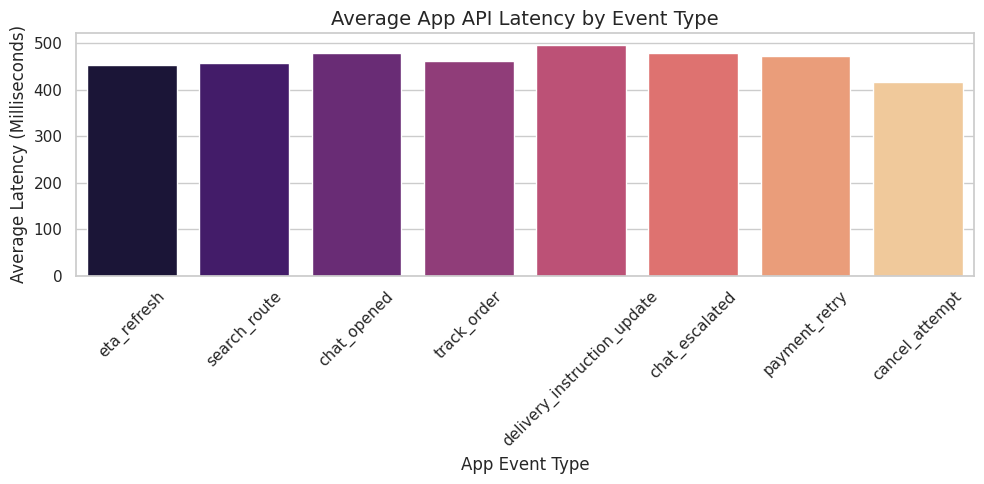

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=app_events, x='event_type', y='api_latency_ms', estimator=np.mean, errorbar=None, palette='magma')
plt.title("Average App API Latency by Event Type", fontsize=14)
plt.xlabel("App Event Type")
plt.ylabel("Average Latency (Milliseconds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart_4.png')
plt.show()

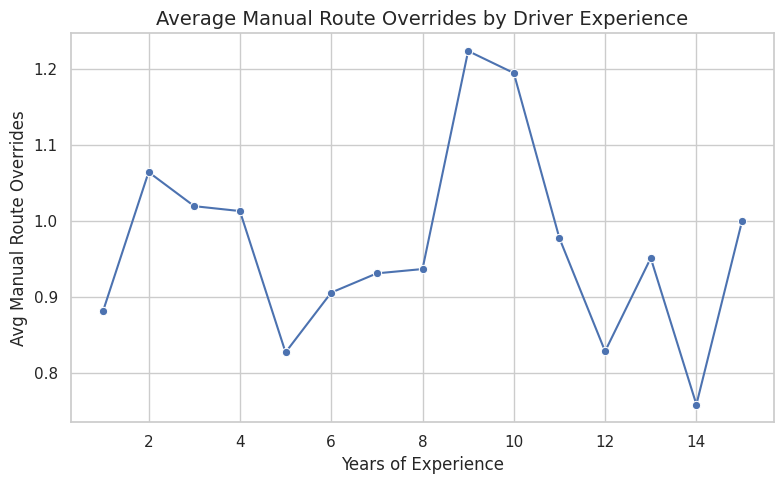

In [9]:
del_drivers = deliveries.merge(drivers, on='driver_id', how='left')

plt.figure(figsize=(8, 5))
sns.lineplot(data=del_drivers, x='years_experience', y='manual_route_override_count', estimator=np.mean, marker='o', errorbar=None)
plt.title("Average Manual Route Overrides by Driver Experience", fontsize=14)
plt.xlabel("Years of Experience")
plt.ylabel("Avg Manual Route Overrides")
plt.tight_layout()
plt.savefig('chart_5.png')
plt.show()